# Regressão Linear
<br/>
<br/>

## Conteúdo

- [Resumo](#resumo)
- [Justificativa matemática](#justificativa_matematica)
- [Desenhando e testando o algoritmo](#desenhando_e_testando_o_algoritmo)
- [Indo um pouco além: Projeção com Erros Ortogonais](#indo_um_pouco_alem)
- [Recomendações e Considerações Finais](#recomendacoes_e_consideracoes_finais)
- [Referências](#referencias)

<br/>
<a id='resumo'></a>

## Resumo

O objetivo da tarefa de regressão é estimar um valor a partir do relacionamento de duas ou mais variáveis. Por exemplo, qual a relação de características como área, quantidade de quartos e localização com o valor de um imóvel?

Essa relação é representada por uma equação matemática, onde a previsão é realizada calculando a soma ponderada das características de entrada, mais uma constante chamada coeficiente linear.

Exemplo:

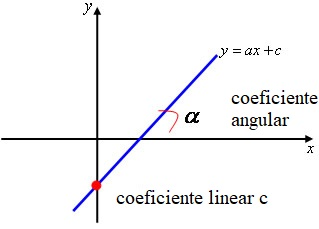

$\hat{y} =w_0+w_1x₁+w_2x₂+...+w_nxₙ$

* ŷ é o valor previsto;
* n é o número de características;
* $x_i$ é o valor da i-ésima característica;
* $w_0$ é o coeficiente linear, valor onde a reta corta o eixo das ordenadas (y);
* $w_i$ é o peso da i-ésima característica.

A equação anterior pode ser escrita na forma vetorizada:

$\hat{y}=h_\hat{w}(x)=\hat{w}^Tx$

* $\hat{w}$ é o vetor de parâmetro do modelo ($w_0$, $w_1$, … , $w_n$);
* $\hat{w}^T$ é a transposição de $\hat{w}$;
* x é o vetor de características ($x_0$, $x_1$, … , $x_n$);
* $h_\hat{w}$ é a função de hipótese.

Ao treinar um modelo de regressão linear, estamos interessados em obter o valor de $w$ que minimize a função de custo. Uma função de custo tipicamente utilizada em problemas de regressão é o MSE (Erro Quadrático Médio):

$MSE(X, h_w) = \frac{1}{m} \sum_{i=1}^{m}(\hat{w}^Tx^i - y^i)^2$

* $m$ é o número de instâncias no conjunto de dados.
* $\hat{w}^T$ é a transposição do vetor de parâmetro do modelo.
* $x^{(i)}$ é o vetor contendo os valores das características e yⁱ seus respectivos rótulos.
* X é uma matriz das características.
* $h_\hat{w}$ é a função de hipótese.

O Erro Quadrático Médio nos informa a que distância a reta de regressão está do conjunto de dados. Calculando o erro (distância entre os pontos e a reta) e elevando ao quadrado (para remover sinais negativos), dando maior peso para grandes erros. A reta com o melhor ajuste possível é a que fornece o menor erro quadrático médio.

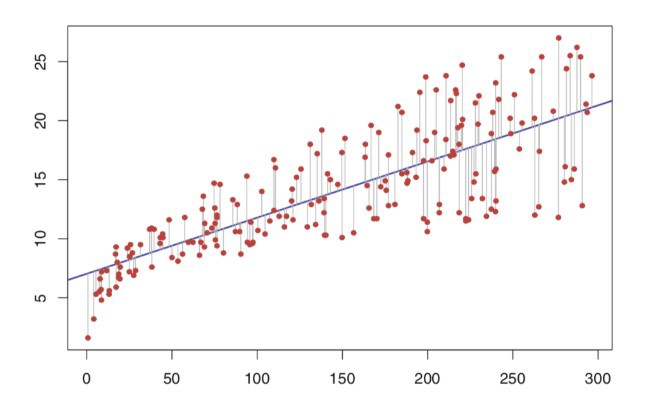
<center>Reta de regressão e desvios dos pontos analisados</center>


* os pontos vermelhos são o conjunto de dados.
* a reta azul é a reta de regressão.
* a linha entre cada ponto e a reta são os erros.

Para encontrar o valor de $\hat{w}$ que minimize a função MSE, existe o Método dos Mínimos Quadrados:

$$ \pmb{\hat{w}} = (X^T X)^{-1} X^T \pmb{y}$$

* $\hat{w}$ é o valor de $w$ que minimiza a função custo.
* $y$ é o vetor dos valores do alvo.

A complexidade computacional ao treinar um modelo de Regressão Linear utilizando o Método dos Mínimos Quadrados é linear em relação ao número de instâncias e características. Dessa forma, ao dobrar a quantidade de instâncias que desejamos prever, iremos dobrar o tempo necessário para realizar a previsão.

Vamos gerar um conjunto de dados lineares e calcular θ̂ usando o Método dos Mínimos Quadrados.

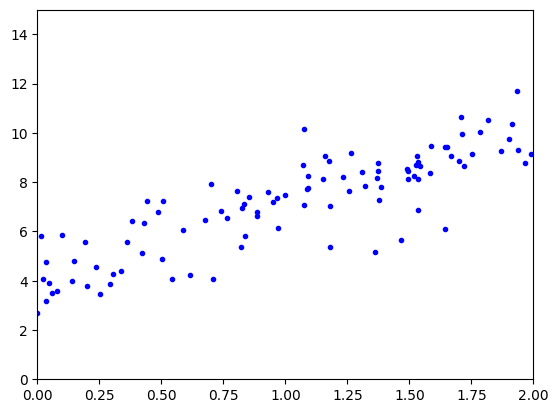

In [1]:
#import
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# números randômicos
# serão dados de treinamento aleatório
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

Nosso objetivo é encontrar a reta que melhor se ajusta ao nosso conjunto de treinamento. Esta reta é definida pela equação:

$y = w_0 + w_1x + ε $

* $w_0$ é o coeficiente linear.
* $w_1$ é o coeficiente angular.
* ε é o ruído gaussiano.
Vamos obter $w_0$ e $w_1$ através do Método dos Mínimos Quadrados:


In [2]:
X_b = np.c_[np.ones((100, 1)), X]
w_chapeu_param = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [3]:
print('coeficiente linear', w_chapeu_param[0], 'coeficiente angular', w_chapeu_param[1])

coeficiente linear [4.13985116] coeficiente angular [2.93428515]


Obtemos $w_0$ = 3.871 e $w_1$ = 3.127. A equação utilizada para gerar os dados foi 𝑦 = 4+3𝑥, a diferença entre o valor utilizado e o obtido é causado pelo ruído gaussiano. Agora que temos $w$, podemos fazer previsões:


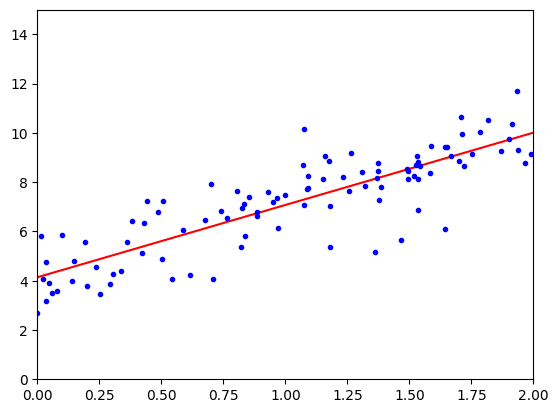

In [4]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(w_chapeu_param)

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [5]:
X_new

array([[0],
       [2]])

O código equivalente utilizando a biblioteca Scikit-Learn:


In [6]:
#importar
from sklearn.linear_model import LinearRegression

# instanciar
linear_reg = LinearRegression()

#treinar
linear_reg.fit(X, y)

linear_reg.intercept_ #coeficiente linear
linear_reg.coef_ #coeficiente angular

# predição
predicao=linear_reg.predict(X_new)

print('coeficiente linear sklearn', linear_reg.intercept_, 'coeficiente angular sklearn', linear_reg.coef_)

print('predicao\n', predicao, '\npara entrada de teste\n' , X_new)

coeficiente linear sklearn [4.13985116] coeficiente angular sklearn [[2.93428515]]
predicao
 [[ 4.13985116]
 [10.00842146]] 
para entrada de teste
 [[0]
 [2]]


Cross Validation ou Validação Cruzada

A Validação Cruzada testa como o modelo se comporta diante de dados que não foram usados como treinamento.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import SCORERS

resultado = cross_val_score(linear_reg, X, y, cv = 4)
print('scores',resultado)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,   random_state=0)

resultado = cross_val_score(linear_reg, X_test, y_test, cv = 4)
print('scores',resultado)

# print(SCORERS.keys()) para obter parâmetros para scoring
# resultado = cross_val_score(linear_reg, X_test, y_test, cv = 3, scoring='neg_mean_squared_error'

scores [0.82223634 0.65438782 0.82428893 0.47441845]
scores [0.5048314  0.75189325 0.88307144 0.72775689]


## Métricas para regressão
https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

In [8]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from math import sqrt

Y_prev=linear_reg.predict(X_test)
print(f'MAE-Mean Absolute Error ou Erro Médio Absoluto {mean_absolute_error(y_test, Y_prev)}')

print(f'MSE Mean Squared Error ou Erro Médio Quadrático {mean_squared_error(y_test, Y_prev)}')

rms = sqrt(mean_squared_error(y_test, Y_prev))
print(f'RMSE Root Mean Squared Error ou raiz do erro quadrático médio {mean_squared_error(y_test, Y_prev)}')


MAE-Mean Absolute Error ou Erro Médio Absoluto 0.9158050549182785
MSE Mean Squared Error ou Erro Médio Quadrático 1.3753917683992631
RMSE Root Mean Squared Error ou raiz do erro quadrático médio 1.3753917683992631


<a id='justificativa_matematica'></a>

## Justificativa matemática

Imagine que temos dados em tabelas, sendo que cada linha é uma observação e cada coluna uma variável. Nos então escolhemos uma das colunas para ser nossa variável dependente y (aquela que queremos prever) e as outras serão as variáveis independentes (X). Nosso objetivo é aprender como chegar das variáveis independentes na variável dependente, ou, em outras palavras, prever y a partir de X. Note, que X é uma matriz nxd, em que n é o número de observações e d o número de dimensões; y é um vetor coluna nx1. Podemos definir o problema como um sistema de equações, em que cada equação é uma observação:

$\begin{cases}
w_0 + w_1 x_1 + ... + w_d x_1 = y_1 \\
w_0 + w_1 x_2 + ... + w_d x_2 = y_2 \\
... \\
w_0 + w_1 x_n + ... + w_d x_n = y_n \\
\end{cases}$

Normalmente, $n > d$, isto é, temos mais observações que dimensões. Sistemas assim costumam não ter solução; há muitas equações e poucas variáveis para ajustar. Intuitivamente, pense que, na prática, muitas coisas afetam a variável y. Principalmente se ela for algo de interesse das ciências humanas, como, por exemplo, preço, desemprego, felicidade... E muitas das coisas que afetam y não podem ser coletadas como dados; as equações acima não tem solução porque não temos todos os fatores que afetam y.

Para lidar com esse problema, vamos adicionar nas equações um termo erro $\varepsilon$ que representará os fatores que não conseguimos observar, erros de medição, etc.

$$\begin{cases}
w_0 + w_1 x_{11} + ... + w_d x_{1d} +  \varepsilon_1 = y_1 \\
w_0 + w_1 x_{21} + ... + w_d x_{2d} + \varepsilon_2 = y_2 \\
... \\
w_0 + w_1 x_{n1} + ... + w_d x_{nd} + \varepsilon_n = y_n \\
\end{cases}$$

Em forma de matriz:

$$ \begin{bmatrix}
    1 & x_{11} & ... & x_{1d} \\
    1 & x_{21} & ... & x_{2d} \\
    \vdots &  \vdots&  \vdots &  \vdots \\
    1 & x_{n1} & ... & x_{nd} \\
\end{bmatrix}
\times
\begin{bmatrix}
    w_0 \\
    w_1 \\
    \vdots \\
    w_d \\
\end{bmatrix}
+
\begin{bmatrix}
    \varepsilon_0 \\
    \varepsilon_1 \\
    \vdots \\
    \varepsilon_n \\
\end{bmatrix}
=
\begin{bmatrix}
    y_0 \\
    y_1 \\
    \vdots \\
    y_n \\
\end{bmatrix}$$


$$X_{nd} \pmb{w}_{d1} + \pmb{\epsilon}_{n1} = \pmb{y}_{n1}$$



Para estimar a equação acima, usaremos a técnica de  [Mínimos Quadrados Ordinários (MQO)](https://pt.wikipedia.org/wiki/M%C3%A9todo_dos_m%C3%ADnimos_quadrados) : queremos achar os $\pmb{\hat{w}}$ que minimizam os $n$ $ \varepsilon^2 $, ou, na forma de vetor, $\pmb{\epsilon}^T \pmb{\epsilon}$. Por que minimizar os erros quadrados? Bom, não há uma resposta certa para isso. Note que os erros variam para mais e para menos e tem média zero, de forma que a soma deles será sempre muito próxima de zero. Então temos que fazer algo para que todos os erros sejam positivos. Poderíamos minimizar os erros absolutos, mas a o quadrado dos erros também funciona e deixa a matemática bem mais simples:

\begin{equation}
\begin{split}
    \pmb{\epsilon}^T  \pmb{\epsilon} &= (\pmb{y} - \pmb{\hat{w}}X)^T(\pmb{y} - \pmb{\hat{w}} X) \\
             &= \pmb{y}^T \pmb{y} - \pmb{\hat{w}}^T X^T \pmb{y} - \pmb{y}^T X \pmb{\hat{w}} + \pmb{\hat{w}} X^T X \pmb{\hat{w}} \\
             &= \pmb{y}^T \pmb{y} - 2\pmb{\hat{w}}^T X^T \pmb{y} + \pmb{\hat{w}} X^T X \pmb{\hat{w}}
\end{split}
\end{equation}

Aqui, usamos o fato que que $\pmb{\hat{w}}^T X^T \pmb{y}$ e $\pmb{y}^T X \pmb{\hat{w}}$ são simplesmente escalares $1x1$ e a transposta de um escalar é o mesmo escalar: $\pmb{\hat{w}}^T X^T \pmb{y} = (\pmb{\hat{w}}^T X^T \pmb{y})^T = \pmb{y}^T X \pmb{\hat{w}}$. Derivando em $\pmb{\hat{w}}$ :


$$\frac{\partial \pmb{\epsilon}^T \pmb{\epsilon}}{\partial \pmb{\hat{w}}} = -2X^T\pmb{y} + 2X^T X \pmb{\hat{w}} = 0$$


Derivando mais uma vez chegamos em $2X^TX$, que é positiva definida se as colunas de X forem independentes. Temos então um ponto de mínimo quando:


$$ \pmb{\hat{w}} = (X^T X)^{-1} X^T \pmb{y}$$


Bom, parece que chegamos em algo interessante. Nos nossos dados temos $X$ e $\pmb{y}$, então podemos achar $\hat{\pmb{w}}$ facilmente: basta substituir os valores na fórmula! O próximo passo e desenhar o algoritmo e ver como ele se sai em dados reais.

OBS:  
1) Seria possível chegar em uma fórmula para os vários $\hat{w_i}$ apenas com cálculo multivariado, sem usar álgebra linear. Embora a forma com álgebra linear seja mais difícil ela vai nos ajudar no entendimento de como o algoritmo funciona. Álgebra linear é uma ferramente poderosa de abstração e a vasta maioria dos algoritmos de aprendizado de máquina usam álgebra linear em suas derivações.

<br/>
<a id='desenhando_e_testando_o_algoritmo'></a>

## Projetando e testando o algoritmo

In [9]:
#instalando pandas
!pip install pandas
#instalando numpy
!pip install numpy
#instalando sklearn que será nossa ferramenta de trabalho nos próximos algoritmos
!pip install sklearn
#para plotar gráficos
!pip install matplotlib

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [10]:
import pandas as pd # para ler os dados em tabela
import sklearn as sk
import matplotlib as mpl
print('imprime a versão do pandas', pd.__version__)
print('imprime a versão do sklearn', sk.__version__)
print('imprime a versão do matplotlib', mpl.__version__)

imprime a versão do pandas 1.5.3
imprime a versão do sklearn 1.2.2
imprime a versão do matplotlib 3.7.1


In [ ]:
import pandas as pd # para ler os dados em tabela
import numpy as np # para álgebra linear
from sklearn import linear_model, model_selection, datasets # para comparar o nosso algoritmo com o de mercado
import matplotlib.pyplot as plt # para fazer gráficos
from matplotlib import style
from time import time # para ver quanto tempo demora
style.use('ggplot') # para gráficos bonitos
np.random.seed(1) # para resultados consistentes

#Estamos criando uma classe em python para explicar o funcionamento do algoritmo de regressão linear
class linear_regr(object):

    def __init__(self):
        pass

    def fit(self, X_train, y_train):
        # adiciona coluna de 1 nos dados
        # insert(arr, obj, values, axis=None)
        # Inserir valores ao longo do eixo especificado antes dos índices especificados.
        X = np.insert(X_train, 0, 1, 1)
        # estima os w_hat
        w_hat = np.dot( np.dot( np.linalg.inv(np.dot(X.T, X)), X.T), y_train)
                                    # (X^T * X)^-1 * X^T * y
        self.w_hat = w_hat
        self.coef = self.w_hat[1:]      # coeficientes
        self.intercept = self.w_hat[0]  # valor quando y=0 coeficientes linear

    def predict(self, X_test):
        X = np.insert(X_test, 0, 1, 1) # adiciona coluna de 1 nos dados
        y_pred = np.dot(X, self.w_hat) # X * w_hat = y_hat
        return y_pred


Ok, teoria justificada e algoritmo pronto. Vamos ver se ele consegue aprender os $\hat{\pmb{w}}$ de dados reais.
OBS: Os dados podem ser encontrados em http://www.cengage.com/aise/economics/wooldridge_3e_datasets/.  
  
  
Lendo e processando os dados:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd '/content/drive/MyDrive/2_2023 - Mineração de Dados/Aula 7 - Algoritmos de regressão: Regressão Linear'

In [ ]:
data = pd.read_csv('hprice.csv', sep=',').iloc[:, :6] # lendo os dados
data.fillna(-99999, inplace = True) # preenchendo valores vazios
X = np.array(data.drop(['price'], 1)) # escolhendo as variáveis independentes
y = np.array(data['price']) # escolhendo a variável dependente

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#test_size - deve estar entre 0,0 e 1,0 e representar a proporção do conjunto de dados a ser incluído na divisão de teste.
#Se int, representa o número absoluto de amostras de teste. Se Nenhum, o valor é definido como o complemento do tamanho do treino.
# Se train_size também for None, será definido como 0,25.

#random_state - Controla o embaralhamento aplicado aos dados antes de aplicar a divisão.
# Passe um int para saída reproduzível em várias chamadas de função.
# É útil se você deseja resultados reproduzíveis, por exemplo, na documentação, para que todos possam ver consistentemente
# os mesmos números ao executar os exemplos.
# Na prática, eu diria que você deve definir o random_state como um número fixo enquanto você testa coisas,
# mas depois removê-lo na produção se você realmente precisar de uma divisão aleatória (e não fixa).

# separa em bases de treino e teste
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 0.3, random_state=1)
data.head(5)

Treinando, testando e comparando o regressor.

In [ ]:
t0 = time()
regr = linear_regr()
regr.fit(X_train, y_train)
print("Tempo do criado manualmente:", round(time()-t0, 3), "s")

# medindo os erros
y_hat = regr.predict(X_test) # prevendo os preços

print('Média do erro absoluto: ', np.absolute((y_hat - y_test)).mean())
print('Média do erro relativo: ', np.absolute(((y_hat - y_test) / y_test)).mean())


# comparando com api do mercado
# Importante - Neste ponto estamos usando sklearn
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train) # ponto do treinamento
print("\n\nTempo do de mercado:", round(time()-t0, 3), "s")

# medindo os erros
y_hat = regr.predict(X_test) # prevendo os preços
w_hat = regr.intercept_
w_hat = np.append(w_hat, regr.coef_)

print('Média do erro absoluto: ', np.absolute((y_hat - y_test)).mean())
print('Média do erro relativo: ', np.absolute(((y_hat - y_test) / y_test)).mean())

print('\ncoeficiente linear\n', regr.intercept_, '\ncoeficientes \n', regr.coef_, '\nw_hat contém coeficientes e na posição zero tem coeficiente linear \n', w_hat)

Nada mal... O erro previsto é, na média, apenas 12,2% diferente do preço real/observado. Note que o algoritmo aprendeu os parâmetros $\hat{\pmb{w}}$ com uma parte dos dados e usou para prever dados que nunca tinha visto, mostando uma boa capacidade de generalização.

O nosso algoritmo produz os mesmos resultados do de mercado, então podemos saber que não erramos nada. Além disso, o nosso algoritmo é mais rápido que o de mercado, mas essa diferênça é insignificante, em termos práticos. Cabe aqui uma observação: **não reinvente a roda!**. Na prática, se existe um bom algorítmo já feito, use-o! Não é preciso fazer o algorítmo do zero sempre, basta importar o do [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)! Aqui, estamos recriando os algorítmos apenas para melhor entendimento de como ele funciona, mas não com intenção de usar nossa criação na prática. Além disso, os algorítmos já pronto são muito melhores e mais rápidos que o nosso. O modelo de regressão linear é apenas uma exceção devido à sua simplicidade


A vantagem do modelo de regressão linear é o que chamamos de um modelo caixa branca: nos sabemos exatamente como ele aprende os parâmetros e ainda nos oferece capacidade interpretativa por meios deles.

Outra vantagem da regressão linear por MQO é que o processo de treinamento é rápido de treinar. Mesmo com milhões de dados, é possível estimar os parâmetros em menos de um segundo. Além disso, uma vez treinado, o regressor ocupa muito pouco espaço, pois só armazena o vetor $\pmb{\hat{w}}$.

Vale uma nota de atenção: esse algoritmo é a base da econometria e da ciência de dados inferencial no geral. Ainda há problemas de iferência (saber se os coeficientes são estatisticamente significantes), de interpretação em outras escalar, de hipóteses assumidas e o que fazer quando elas são violadas.

In [ ]:
# Código para os gráficos:
%matplotlib inline
np.random.seed(42)
x = np.linspace(-15,15, 20)
y = x * .5 + 2 + np.random.normal(0,2,size=20)
plt.scatter(x, y)
plt.xlabel('$X$')
plt.ylabel('$y$')
plt.show()

plt.scatter(x, y)
plt.scatter(1, 1 * .5 + 2, c='C4', s=100) # x=1
plt.plot(x, x * .5 + 2, c='C1')
plt.xlabel('$X$')
plt.ylabel('$y$')
plt.show()
%matplotlib notebook

<a id='recomendacoes_e_consideracoes_finais'></a>   

## Recomendações e Considerações Finais
O modelo de regressão linear acha um hiperplano linear que minimiza a soma dos resíduos quadrados entre a variável dependente (saída) prevista pelo hiperplano e a variável dependente observada. Para estimar os parâmetros $\pmb{w}$ do hiperplano é necessário que nenhuma das variáveis independentes (entradas) seja combinação linear de outras. A não linearidade pode ser facilmente introduzida no modelo por meio de transformações diretamente nas variáveis dependentes. Essas transformações podem ser logaritmo de uma variável, quadrado de uma variável, etc.

Em problemas de aprendizado de máquina, é recomendável utilizar o modelo de regressão linear como uma primeira tentativa, devido à sua simplicidade e capacidade interpretativa. Das vantagens do modelo de regressão linear podemos destacar:

1) É de fácil interpretação. A variável de saída $y$ pode ser vista como uma soma das variáveis de entrada $X$ ponderada pelos parâmetros $w$. Assim, é possível saber diretamente qual variável de $X$ mais contribui para a variável de saída: a correspondente ao parâmetros com maior valor absoluto.  
2) É um modelo rápido de treinar, uma vez que o ponto de minimização dos erros quadrados pode ser encontrada analiticamente, sem necessidade de métodos iterativos.  
3) Uma vez treinado, o regressor ocupa pouco espaço de RAM.  
4) Produz bons resultados preditivos. Normalmente, o erro do modelo linear é apenas um pouco mais alto do que os obtidos com algoritmos de aprendizado de máquina mais complexo.  

No entanto, o modelo vem com sérias desvantagens, o que nos motivará a procurar outros algoritmos mais complexos e melhores:

1) A não linearidade tem que ser incluída à mão. O modelo não aprende a forma que se dão as relações não lineares.  
2) Não é robusto à outliers. Não representa bem certas estruturas de dado, como pode ser visto no [Quarteto de Anscombe](https://pt.wikipedia.org/wiki/Quarteto_de_Anscombe), podendo produzir resultados enganosos.  
3) Se duas variáveis de $X$ são altamente correlacionadas, o modelo vai ser sensível ao ruído. Recomenda-se utilizar Análise de Componentes Principais nas variáveis altamente correlacionadas e alimentar o modelo linear apenas com o primeiro componente principal.  

<br/>
<a id='referencias'></a>   

## Referências

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

https://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression-extending-linear-models-with-basis-functions

<br/>
